In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/xahidbuffon/FUnIE-GAN.git

%cd /content/FUnIE-GAN/PyTorch

!ls
!ls models

Cloning into 'FUnIE-GAN'...
remote: Enumerating objects: 1088, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 1088 (delta 17), reused 16 (delta 16), pack-reused 1059 (from 1)
Receiving objects: 100% (1088/1088), 126.27 MiB | 23.07 MiB/s, done.
Resolving deltas: 100% (622/622), done.
/content/FUnIE-GAN/PyTorch
configs  nets	    test.py	       train_ugan.py
models	 README.md  train_funiegan.py  utils
funie_discriminator.pth  funie_generator.pth


In [3]:
from google.colab import files
import os
import shutil
import zipfile

uploaded = files.upload()

zip_name = list(uploaded.keys())[0]

input_folder = "/content/input_images"
output_folder = "/content/output_image"

shutil.rmtree(input_folder, ignore_errors=True)
shutil.rmtree(output_folder, ignore_errors=True)

os.makedirs(input_folder, exist_ok=True)
os.makedirs(output_folder, exist_ok=True)

with zipfile.ZipFile(zip_name, "r") as zip_ref:
    zip_ref.extractall(input_folder)

print("ZIP extracted successfully!")

Saving dataset5.zip to dataset5.zip
ZIP extracted successfully!


In [4]:
import os

for root, dirs, files in os.walk(input_folder):
    print(root)
    for f in files:
        print("   ", f)

/content/input_images
/content/input_images/dataset5
    im3.jpg
    im1.jpg
    im4.jpg
    im5.jpg
    im2.jpg


In [5]:
from pathlib import Path

test_path = Path("/content/FUnIE-GAN/PyTorch/test.py")

text = test_path.read_text()

# Save only enhanced image
old1 = """img_sample = torch.cat((inp_img.data, gen_img.data), -1)
    save_image(img_sample, join(opt.sample_dir, basename(path)), normalize=True)
    print ("Tested: %s" % path)"""

new1 = """save_image(
        gen_img.data,
        join(opt.sample_dir, basename(path)),
        normalize=True
    )

    print(f"Enhanced: {basename(path)}")"""

text = text.replace(old1, new1)

# Recursive image search
old2 = 'test_files = sorted(glob(join(opt.data_dir, "*.*")))'
new2 = 'test_files = sorted(glob(join(opt.data_dir, "**", "*.*"), recursive=True))'

text = text.replace(old2, new2)

test_path.write_text(text)

print("✅ test.py updated successfully!")

✅ test.py updated successfully!


In [6]:
!python /content/FUnIE-GAN/PyTorch/test.py \
--data_dir "/content/input_images" \
--sample_dir "/content/output_image" \
--model_name funiegan \
--model_path "/content/FUnIE-GAN/PyTorch/models/funie_generator.pth"

Loaded model from /content/FUnIE-GAN/PyTorch/models/funie_generator.pth
Enhanced: im1.jpg
Enhanced: im2.jpg
Enhanced: im3.jpg
Enhanced: im4.jpg
Enhanced: im5.jpg

Total samples: 5
Time taken: 0 sec at 364.540 fps
Saved generated images in in /content/output_image



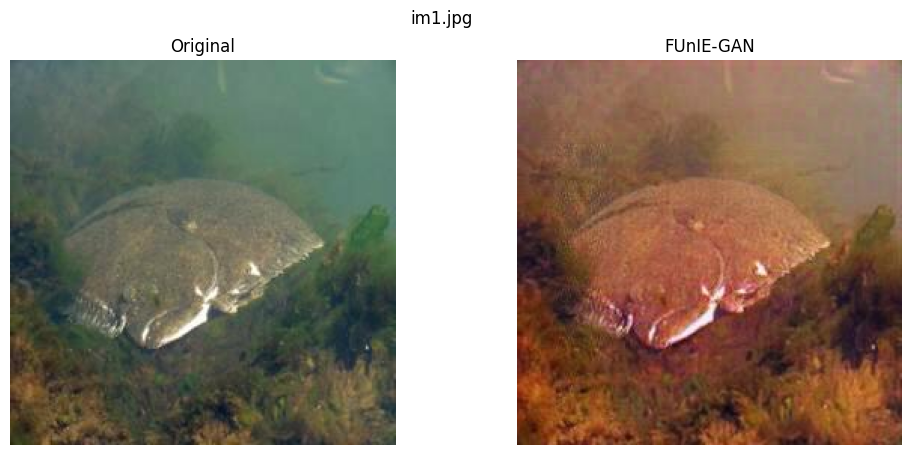

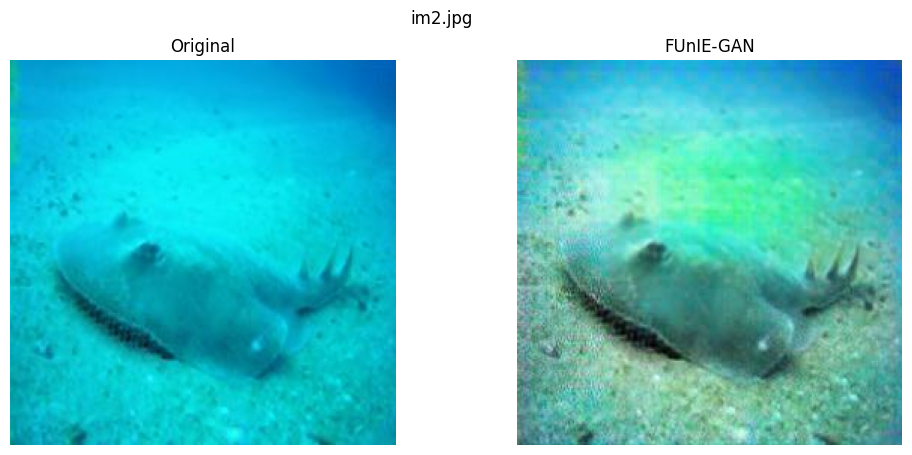

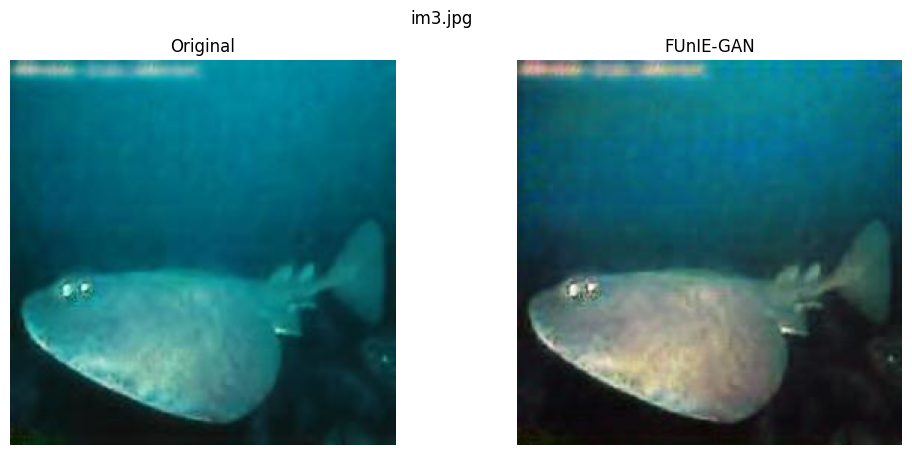

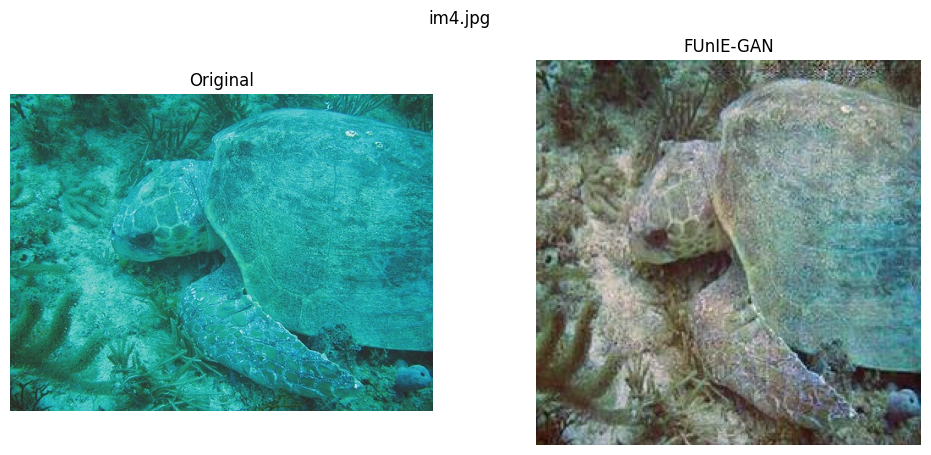

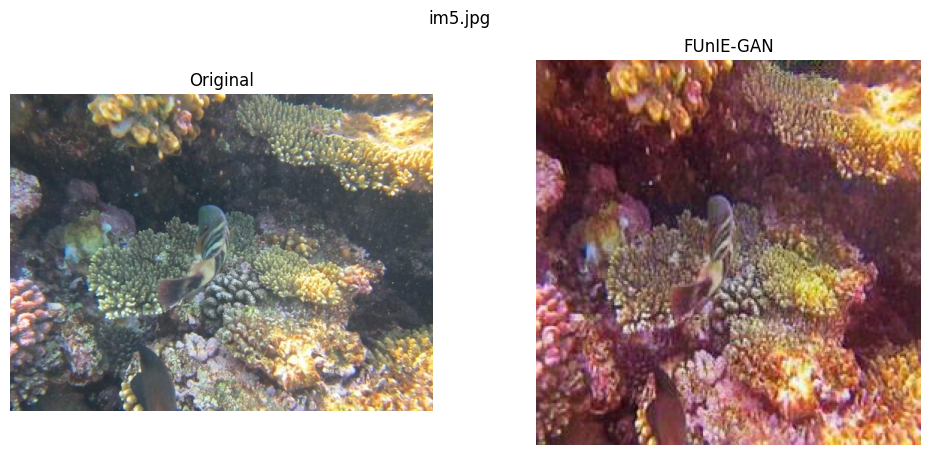

In [7]:
import os
import matplotlib.pyplot as plt
from PIL import Image

extensions = (".jpg", ".jpeg", ".png", ".bmp")

for root, dirs, files in os.walk(input_folder):

    for file in sorted(files):

        if not file.lower().endswith(extensions):
            continue

        original_path = os.path.join(root, file)

        # Output images are saved directly in output_image
        enhanced_path = os.path.join(output_folder, file)

        if not os.path.exists(enhanced_path):
            print(f"Missing: {enhanced_path}")
            continue

        original = Image.open(original_path)
        enhanced = Image.open(enhanced_path)

        plt.figure(figsize=(12,5))

        plt.subplot(1,2,1)
        plt.imshow(original)
        plt.title("Original")
        plt.axis("off")

        plt.subplot(1,2,2)
       	plt.imshow(enhanced)
        plt.title("FUnIE-GAN")
        plt.axis("off")

        plt.suptitle(file)

        plt.show()

In [8]:
import os
import shutil

drive_output = "/content/drive/MyDrive/FUnIEGAN_Output"

os.makedirs(drive_output, exist_ok=True)

# Copy all enhanced images
for file in os.listdir(output_folder):
    src = os.path.join(output_folder, file)
    dst = os.path.join(drive_output, file)
    shutil.copy2(src, dst)

print("✅ Enhanced images saved to:", drive_output)

✅ Enhanced images saved to: /content/drive/MyDrive/FUnIEGAN_Output


In [9]:
!pip install opencv-python-headless pandas scipy

In [10]:
import cv2
import numpy as np
from scipy import ndimage

In [11]:
def uciqe(img):

    img_lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB).astype(np.float32)

    L = img_lab[:,:,0] / 255.0
    a = img_lab[:,:,1]
    b = img_lab[:,:,2]

    chroma = np.sqrt(a*a + b*b)

    sigma_c = np.std(chroma)

    con_l = np.percentile(L,99) - np.percentile(L,1)

    sat = chroma / np.sqrt(chroma**2 + L**2 + 1e-6)
    mu_s = np.mean(sat)

    return 0.4680*sigma_c + 0.2745*con_l + 0.2576*mu_s

In [12]:
def eme(channel, blocksize=8):

    h,w = channel.shape

    eme_val = 0

    k1 = h//blocksize
    k2 = w//blocksize

    for i in range(k1):
        for j in range(k2):

            block = channel[
                i*blocksize:(i+1)*blocksize,
                j*blocksize:(j+1)*blocksize
            ]

            max_ = np.max(block)
            min_ = np.min(block)

            if min_ > 0:
                eme_val += np.log(max_/min_)

    return (2/(k1*k2))*eme_val


def uiqm(img):

    img = img.astype(np.float32)

    R,G,B = cv2.split(img)

    rg = R-G
    yb = (R+G)/2-B

    uicm = np.std(rg)+np.std(yb)

    gray = cv2.cvtColor(img.astype(np.uint8),cv2.COLOR_BGR2GRAY)

    uism = eme(gray)

    uiconm = np.std(gray)

    return 0.0282*uicm + 0.2953*uism + 3.5753*uiconm

In [13]:
import pandas as pd
import os

results = []

extensions = (".jpg",".jpeg",".png",".bmp")

for file in sorted(os.listdir(output_folder)):

    if not file.lower().endswith(extensions):
        continue

    path = os.path.join(output_folder,file)

    img = cv2.imread(path)

    if img is None:
        continue

    uiqm_score = uiqm(img)
    uciqe_score = uciqe(img)

    results.append({
        "Image":file,
        "UIQM":uiqm_score,
        "UCIQE":uciqe_score
    })

df = pd.DataFrame(results)

df

,Image,UIQM,UCIQE
0,im1.jpg,116.704593,5.206250
1,im2.jpg,128.758436,4.558424
2,im3.jpg,161.048019,6.123611
3,im4.jpg,137.986529,4.126305
4,im5.jpg,178.426738,5.771006


In [14]:
csv_path = "/content/drive/MyDrive/FUnIEGAN_Output/UIQM_UCIQE_Results.csv"

df.to_csv(csv_path,index=False)

print("Saved:",csv_path)

Saved: /content/drive/MyDrive/FUnIEGAN_Output/UIQM_UCIQE_Results.csv
